# Lead Field Electrograms

This tutorial constructs a spatial weighting potential for a pair of surface electrodes and uses it to calculate a bipolar electrogram (EGM) during a cardiac excitation simulation. We build a synthetic tissue geometry, select electrode patches, solve a stationary boundary-value problem, and pass the resulting weights to `EGMTracker`.

An EGM represents extracellular electrical activity sensed by an electrode configuration; it is different from the transmembrane voltage of an individual cell. Reciprocity provides a way to precompute the sensitivity of a fixed lead and reuse it as the cardiac sources evolve. See [Malmivuo and Plonsey, Chapter 11](https://bem.fi/book/11/11.htm) for the theoretical foundation and [Potse (2018)](https://doi.org/10.3389/fphys.2018.00370) for an application to reaction–diffusion heart models.

Here, `weighting_potential` is a **scalar weighting potential**, rather than the vector electric field or current density sometimes called a lead field. Its prescribed-potential normalization makes this an illustrative signal calculation; the resulting amplitude is not calibrated in millivolts.

Run the cells in order in an environment containing NumPy, SciPy, Matplotlib, PyVista, PyAMG, compatible versions of Finitewave and Finitewave-Tools, and JAX for the selected simulation backend. Geometry is generated in memory; no input dataset is required. The 3D grid and sparse solve can require substantial memory, and the first JAX run includes compilation time.

## 1. Construct the tissue and place the electrodes

The grid has shape `(200, 100, 200)`. Setting `distance_seed[grid_size // 2, 0, :] = False` creates a line of zero-valued voxels along the third axis. The Euclidean distance transform measures distance to that line, and retaining distances from 80 to 100 creates a half-annular cross-section extruded along the third axis. This is a synthetic curved wall, not an anatomical ventricle with an apex.

Geometry construction and electrode selection use **grid-index units**; plotted coordinates are converted to spatial units. With the spacing `dr = 0.2 mm`, the nominal wall thickness is `20 * dr = 4 mm` spatial units and the electrode-center separation is `15 * dr = 3mm`. A physical length unit must be chosen consistently with the simulation parameters.

The two centers lie at `[90, 80, 100]` and `[110, 80, 100]`. Blue denotes the negative electrode and orange denotes the positive electrode. All slice figures use spatial coordinates: array axis 1 is horizontal and axis 0 is vertical. Pixel extents and electrode markers are scaled by `dr` so that their centers align.

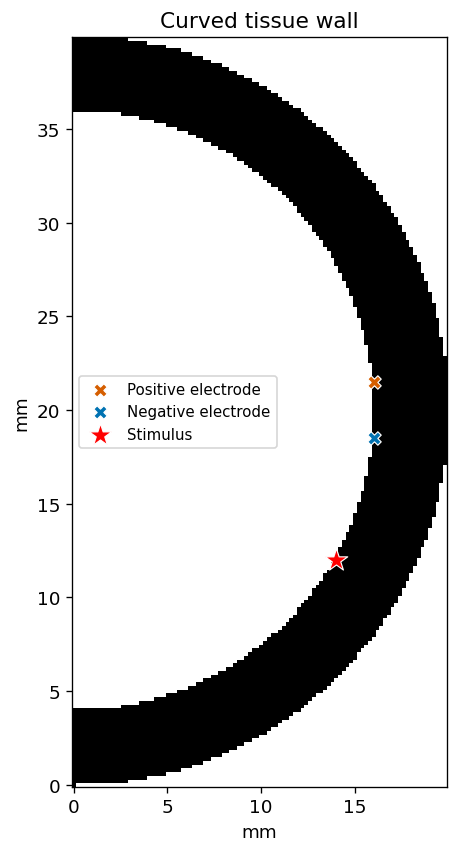

In [22]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from scipy import ndimage, spatial
import finitewave_tools.visualization as fwv

plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 13})
negative_color = "#0072B2"
positive_color = "#D55E00"

# Coordinates used for geometry and electrode selection remain grid indices.
grid_size = 200
dr = 0.2
slice_index = grid_size // 2
inner_radius = grid_size // 2 - 20
outer_radius = grid_size // 2

distance_seed = np.ones((grid_size, grid_size // 2, grid_size), dtype=bool)
distance_seed[grid_size // 2, 0, :] = False
distance_to_axis = ndimage.distance_transform_edt(distance_seed)
tissue_mask = (distance_to_axis >= inner_radius) & (distance_to_axis <= outer_radius)

negative_electrode_center = np.array([grid_size // 2 - 7.5, inner_radius, slice_index])
positive_electrode_center = np.array([grid_size // 2 + 7.5, inner_radius, slice_index])

stimulus_center = np.array([[60, 70, slice_index]], dtype=np.float32)

# Pixel edges place each voxel center at its index multiplied by dr.
slice_extent = (
    -0.5 * dr, (tissue_mask.shape[1] - 0.5) * dr,
    -0.5 * dr, (tissue_mask.shape[0] - 0.5) * dr,
)


fig, ax = plt.subplots(figsize=(5.5, 7), layout="constrained")
ax.imshow(tissue_mask[..., slice_index], cmap="Greys", vmin=0, vmax=1,
          origin="lower", extent=slice_extent, interpolation="nearest")

ax.scatter(positive_electrode_center[1] * dr, positive_electrode_center[0] * dr,
           c=positive_color, s=65, marker="X", edgecolors="white",
           linewidths=0.7, label="Positive electrode", zorder=3)
ax.scatter(negative_electrode_center[1] * dr, negative_electrode_center[0] * dr,
           c=negative_color, s=65, marker="X", edgecolors="white",
           linewidths=0.7, label="Negative electrode", zorder=3)
ax.scatter(stimulus_center[0, 1] * dr, stimulus_center[0, 0] * dr,
           c="red", s=200, marker="*", edgecolors="white",
           linewidths=0.7, label="Stimulus", zorder=3)
ax.set(title="Curved tissue wall", xlabel="mm", ylabel="mm")
ax.set_aspect("equal")
ax.legend(loc="center left", fontsize=9)
plt.show()


## 2. Turn electrode centers into surface patches

Binary erosion removes one layer of tissue; subtracting the eroded mask leaves boundary voxels. `extract_boundary_voxels` includes **all exposed boundaries**, including the inner wall and the ends of the extrusion. A KD-tree selects boundary voxels within a radius of 3 grid units (`0.6` spatial units at the chosen spacing) of each electrode center.

The full grid and the solver use different indexing conventions. `electrode_labels` stores labels on the full 3D grid, whereas `electrode_labels[tissue_mask]` contains only active tissue voxels. Consequently, `negative_electrode_indices` and `positive_electrode_indices` index the compact tissue arrays used by the matrix and tracker; they are not flat indices into the full grid. `np.argwhere(tissue_mask)` follows the same active-voxel ordering.

When changing electrode locations or patch radius, check that both patches are nonempty and disjoint. An empty patch makes the later normalization invalid; overlapping patches would make the electrode assignment ambiguous.

In [23]:
def extract_boundary_voxels(mask):
    """Return all exposed tissue voxels, including inner walls and end faces."""
    return mask & ~ndimage.binary_erosion(mask)


def select_points_within_radius(center, candidate_coordinates, radius):
    tree = spatial.KDTree(candidate_coordinates)
    point_indices = tree.query_ball_point(center, radius)
    return candidate_coordinates[point_indices]


boundary_mask = extract_boundary_voxels(tissue_mask)
boundary_coordinates = np.argwhere(boundary_mask)
electrode_radius = 3
negative_electrode_coordinates = select_points_within_radius(
    negative_electrode_center, boundary_coordinates, electrode_radius,
)
positive_electrode_coordinates = select_points_within_radius(
    positive_electrode_center, boundary_coordinates, electrode_radius,
)
if not len(negative_electrode_coordinates) or not len(positive_electrode_coordinates):
    raise ValueError("Both electrodes must contain at least one boundary voxel.")

electrode_labels = np.zeros(tissue_mask.shape, dtype=np.int8)
electrode_labels[tuple(negative_electrode_coordinates.T)] = -1
if np.any(electrode_labels[tuple(positive_electrode_coordinates.T)] == -1):
    raise ValueError("Positive and negative electrode patches must be disjoint.")
electrode_labels[tuple(positive_electrode_coordinates.T)] = 1

negative_electrode_indices = np.flatnonzero(electrode_labels[tissue_mask] == -1)
positive_electrode_indices = np.flatnonzero(electrode_labels[tissue_mask] == 1)


## 3. Inspect geometry and electrode placement

The gray surface shows the tissue, and the colored points show the selected electrode patches. Use this view to check that the contacts sit on the intended wall. The static PyVista backend embeds a still image in the notebook.

The surface and electrode coordinates both use `dr`. A translucent wall and oblique camera make the contacts visible in three dimensions; the bounds use the same spatial units as the slice plots.

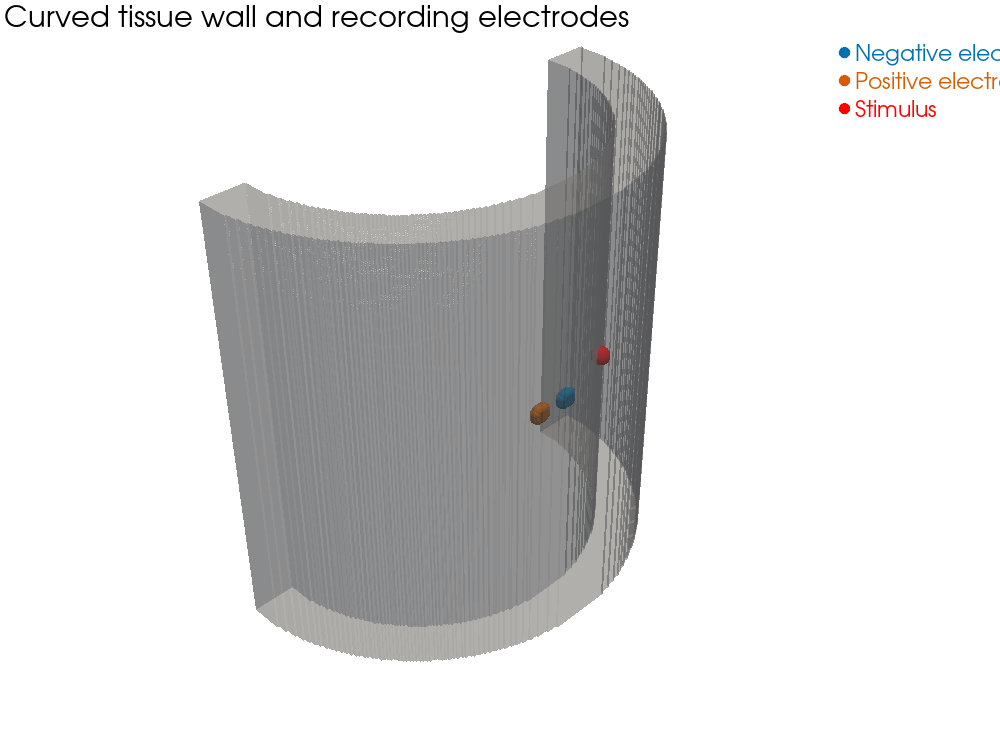

In [28]:
tissue_surface = fwv.PyVistaMeshGrid.from_mesh(
    tissue_mask, dr=dr, as_surface=True,
)
tissue_coordinates = np.argwhere(tissue_mask).astype(np.float32) * dr

pv.set_jupyter_backend("static")
geometry_plotter = pv.Plotter(window_size=(1000, 750))
geometry_plotter.set_background("white")
geometry_plotter.add_text("Curved tissue wall and recording electrodes", font_size=16, color="black")
geometry_plotter.add_mesh(tissue_surface, color="lightgray", opacity=0.45)
geometry_plotter.add_points(
    tissue_coordinates[negative_electrode_indices], color=negative_color,
    point_size=12, render_points_as_spheres=True, label="Negative electrode",
)
geometry_plotter.add_points(
    tissue_coordinates[positive_electrode_indices], color=positive_color,
    point_size=12, render_points_as_spheres=True, label="Positive electrode",
)
geometry_plotter.add_points(
    stimulus_center * dr, color="red", point_size=20, render_points_as_spheres=True,
    label="Stimulus",
)
geometry_plotter.add_legend(bcolor="white", face="circle", size=(0.25, 0.12))
geometry_plotter.camera_position = "iso"
geometry_plotter.show()


## 4. Assemble the stationary spatial operator

`CardiacTissue` supplies the tissue mask and spacing. `IsotropicDiscretization.compute_weights` returns the spatial matrix `spatial_matrix` and mass matrix `mass_matrix`; only `spatial_matrix` is used for the stationary solve below. The boundary stencil handles the tissue boundary as insulating except where we subsequently prescribe electrode potentials.

The continuum problem motivating the solve is

$$
\nabla\cdot(D\nabla\psi)=0
$$

inside the conducting domain, with fixed potentials on the electrode patches and zero normal flux elsewhere. Here $\psi$ is the weighting potential and $D$ is the isotropic coefficient represented by the discretization.

`lead_field_tissue.conductivity = intracellular_diffusion + extracellular_diffusion` is the library's conductivity scaling parameter; this assignment alone does not establish a physical conductivity in S/m. For a homogeneous stationary problem with fixed Dirichlet values, multiplying the entire operator by a nonzero constant leaves the solution unchanged, although it changes the associated flux.

The coefficient names follow the isotropic relation $D_m = D_i D_e / (D_i + D_e)$. The stationary operator uses the sum $D_i + D_e = 0.6$, while `monodomain_diffusion = 0.15` enters the EGM weight scaling below. Computing this value does not assign it to the action-potential model.


In [29]:
import finitewave as fw

intracellular_diffusion = 0.3
extracellular_diffusion = 0.3
monodomain_diffusion = (
    intracellular_diffusion * extracellular_diffusion
    / (intracellular_diffusion + extracellular_diffusion)
)

lead_field_tissue = fw.CardiacTissue(tissue_mask.shape, dr=dr)
lead_field_tissue.mesh = tissue_mask.astype(np.uint8)
lead_field_tissue.conductivity = intracellular_diffusion + extracellular_diffusion

lead_field_discretization = fw.IsotropicDiscretization()
spatial_matrix, mass_matrix = lead_field_discretization.compute_weights(lead_field_tissue)


## 5. Solve for the weighting potential

For patch sizes $N_-$ and $N_+$, the code prescribes

$$
\psi|_{E_-}=-1/N_-,\qquad \psi|_{E_+}=+1/N_+.
$$

These are **Dirichlet potential values**, not injected currents. Dividing by the number of patch nodes does not enforce unit total current. A quantitatively calibrated reciprocal lead would require a consistent electrode-current normalization, source units, and spatial integration weights. The unit-current construction is described in [Malmivuo and Plonsey, Section 11.6](https://bem.fi/book/11/11.htm).

`make_system` separates free nodes $F$ from prescribed nodes $B$. With zero interior load, the reduced system is

$$
K_{FF}\psi_F=-K_{FB}\psi_B.
$$

`boundary_potential` holds the boundary values; `free_node_indices` identifies the free entries. `linear_solver` solves the reduced system using GMRES with an algebraic multigrid preconditioner. Inserting the solution at `inds` reconstructs one potential value per active tissue voxel.

The solve produces `weighting_potential`, denoted $\psi$. The new scaling is kept explicitly separate:

$$
w_j = \psi_j\,\Delta x^3\frac{D_i}{D_m},
\qquad D_m=\frac{D_iD_e}{D_i+D_e}.
$$

Here `dr` is $\Delta x$, `intracellular_diffusion` is $D_i$, `extracellular_diffusion` is $D_e$, and `monodomain_diffusion` is $D_m$. With the current values, $D_m=0.15$ and the weight multiplier is $0.016$. `egm_weights` contains $w_j$ and is passed to the tracker. This includes the voxel-volume and diffusion-ratio factors but does not replace unit-current electrode normalization.

`egm_weight_grid` is a plotting representation of the scaled weights. Empty space is masked, and the diverging color scale is symmetric about zero. A useful solver check is that `reduced_matrix @ weighting_potential[free_node_indices] - reduced_rhs` is small relative to `reduced_rhs`. Check prescribed values on the unscaled `weighting_potential`, rather than on `egm_weights`.

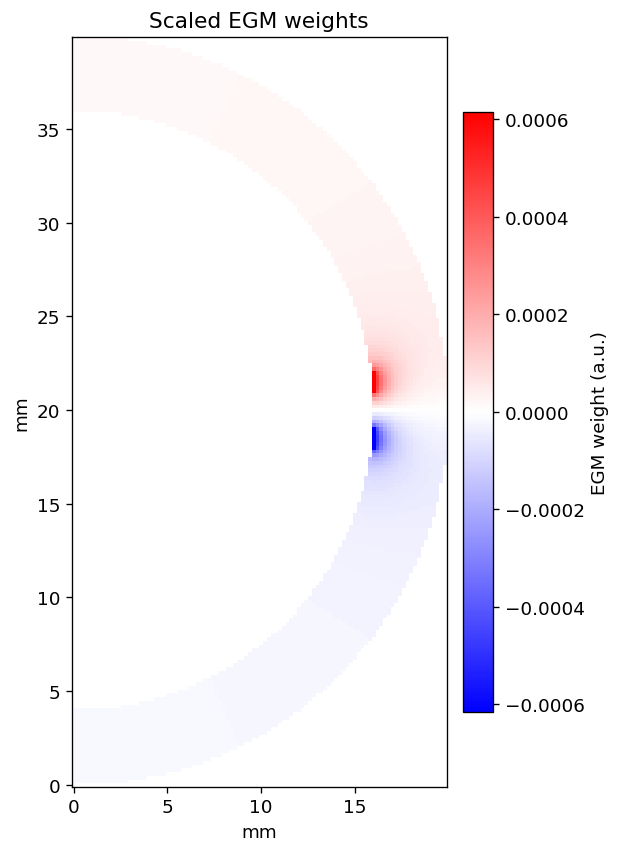

In [32]:
from finitewave_tools.linalg.linalg import make_system, linear_solver

electrode_boundary_conditions = [
    (negative_electrode_indices, -1 / len(negative_electrode_indices)),
    (positive_electrode_indices, 1 / len(positive_electrode_indices)),
]
reduced_matrix, reduced_rhs, boundary_potential, free_node_indices = make_system(
    spatial_matrix, dirichlet_conditions=electrode_boundary_conditions,
)

weighting_potential = boundary_potential.copy()
weighting_potential[free_node_indices] = linear_solver(
    reduced_matrix, reduced_rhs, x0=boundary_potential[free_node_indices],
)
# Preserve the volume and diffusion-ratio scaling separately from the solve.
egm_weight_scale = dr**3 * intracellular_diffusion / monodomain_diffusion
egm_weights = weighting_potential * egm_weight_scale

egm_weight_grid = np.full(tissue_mask.shape, np.nan, dtype=np.float32)
egm_weight_grid[tissue_mask] = egm_weights
weight_slice = np.ma.masked_invalid(egm_weight_grid[..., slice_index])
weight_limit = float(np.max(np.abs(egm_weights)))

fig, ax = plt.subplots(figsize=(6, 7), layout="constrained")
weight_image = ax.imshow(
    weight_slice, cmap="bwr", vmin=-weight_limit, vmax=weight_limit,
    origin="lower", extent=slice_extent, interpolation="nearest",
)
ax.set(title="Scaled EGM weights", xlabel="mm", ylabel="mm")
fig.colorbar(weight_image, ax=ax, shrink=0.8, pad=0.03, label="EGM weight (a.u.)")
plt.show()


## 6. Simulate excitation and accumulate the EGM

The simulation uses the [Luo–Rudy 1991 ventricular action-potential model](https://doi.org/10.1161/01.RES.68.6.1501), with a time step of 0.01 ms and a duration of 30 ms. This short interval focuses on early excitation and propagation rather than a complete repolarization cycle. A current stimulus of model amplitude 100 is applied for 1 ms, starting at time zero, within radius 10 grid units of `[60, 70, 100]`.

The recording electrodes and the stimulation region have separate roles: the former define the spatial weights, and the latter initiate the wave. The `simulation_tissue` uses the same mask and spacing as the weighting calculation, which preserves node correspondence. It does **not** copy the earlier `conductivity = 0.6`; it retains the library default of 1.0. Thus the two tissue objects do not have identical conductivity settings. The cellular model also retains its default diffusion coefficient. In the local Luo–Rudy 1991 implementation this is `D_model = 0.1`, whereas the scaling above uses `monodomain_diffusion = 0.15`. This existing parameter difference is preserved here; quantitative use requires reconciling the scaling coefficient with the diffusion used for propagation.

For the JAX backend used here, the current tracker implementation evaluates

$$
s_j^n=\frac{u_j^{n+1}-u_j^n}{\Delta t}-\mathrm{rhs}_j^n,
\qquad
\mathrm{EGM}^n=\sum_{j\in\mathrm{tissue}}w_j s_j^n,
$$

where `u_old` and `u` are the stored previous and current transmembrane voltages, and `rhs` is the model's stored reaction/stimulus right-hand side. This describes the implemented discrete source estimate; its precise time interpretation follows the simulation's integration scheme.

Passing `lead_fields=egm_weights` supplies the weights directly and bypasses the tracker's inverse-distance weight calculation. In this path the tracker adds no separate voxel-volume or conductivity factor. The supplied weights already include `dr**3 * intracellular_diffusion / monodomain_diffusion`; their absolute amplitude still depends on electrode normalization. The one-dimensional array gives a single signal with the selected JAX backend.

The final slice displays transmembrane voltage at the end of the run with a fixed −90 to 50 mV color scale; color-bar extensions indicate that values outside this range saturate. Empty space is masked, and the stimulus center is marked with a star. It helps locate the propagating wave; it is not an extracellular potential map.

Running LuoRudy91 on (200, 100, 200) Grid: 100%|██████████| 2999/2999 [00:16<00:00, 186.24it/s]


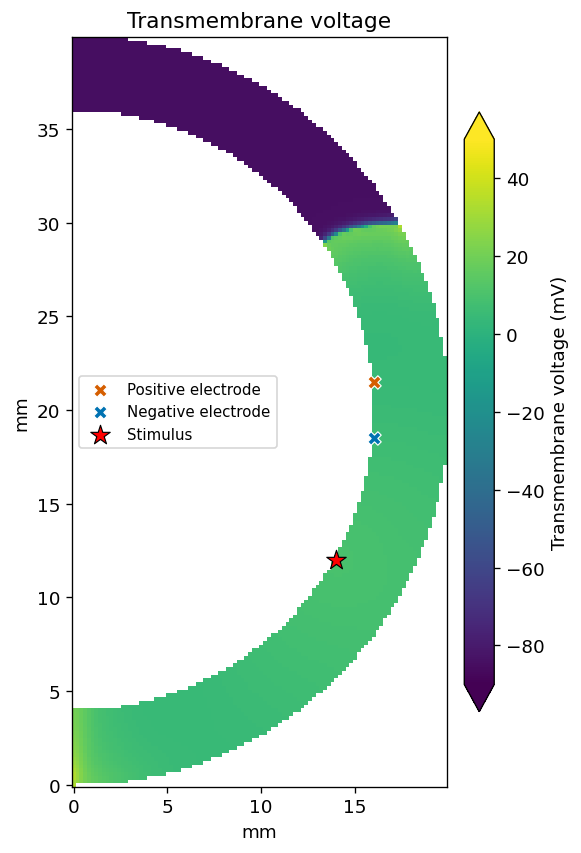

In [34]:
stimulus_center = np.array([[60, 70, slice_index]], dtype=np.float32)
stimulus_start = 0.0
stimulus_duration = 1.0

simulation_tissue = fw.CardiacTissue(tissue_mask.shape, dr=dr)
simulation_tissue.mesh = tissue_mask.astype(np.uint8)

egm_tracker = fw.EGMTracker(lead_fields=egm_weights)

simulation = fw.CardiacSimulation(dt=0.01, t_max=30, backend="jax")
simulation.cardiac_tissue = simulation_tissue
simulation.cardiac_model = fw.LuoRudy91()
simulation.stim_sequence = fw.StimSequence()
simulation.stim_sequence.add_stim(
    fw.StimCurrentElectrodes(
        time=stimulus_start, curr_value=100, duration=stimulus_duration,
        coords=stimulus_center, size=10,
    )
)
simulation.tracker_sequence = fw.TrackerSequence()
simulation.tracker_sequence.add_tracker(egm_tracker)

simulation.run()

transmembrane_voltage = simulation.cardiac_model.u
voltage_slice = np.ma.masked_where(
    ~tissue_mask[..., slice_index], transmembrane_voltage[..., slice_index],
)
fig, ax = plt.subplots(figsize=(6, 7), layout="constrained")
voltage_image = ax.imshow(
    voltage_slice, cmap="viridis", vmin=-90, vmax=50,
    origin="lower", extent=slice_extent, interpolation="nearest",
)

ax.set(title="Transmembrane voltage", xlabel="mm", ylabel="mm")
ax.scatter(positive_electrode_center[1] * dr, positive_electrode_center[0] * dr,
           c=positive_color, s=65, marker="X", edgecolors="white",
           linewidths=0.7, label="Positive electrode", zorder=3)
ax.scatter(negative_electrode_center[1] * dr, negative_electrode_center[0] * dr,
           c=negative_color, s=65, marker="X", edgecolors="white",
           linewidths=0.7, label="Negative electrode", zorder=3)
ax.scatter(stimulus_center[0, 1] * dr, stimulus_center[0, 0] * dr,
           marker="*", s=150, c="red", edgecolors="black",
           linewidths=0.7, label="Stimulus", zorder=4)

ax.legend(loc="center left", fontsize=9)
fig.colorbar(voltage_image, ax=ax, shrink=0.8, pad=0.03,
             label="Transmembrane voltage (mV)", extend="both")
plt.show()


## 7. Plot the bipolar signal against time

`tracking_times` contains the actual sampling times in ms, and `output` contains the corresponding weighted signal. The tracker records every simulation step by default. Interpret the vertical axis as **arbitrary amplitude units** for this normalization. The shaded interval marks the applied stimulus; the horizontal reference line marks zero signal.

The curve combines source contributions throughout the tissue. Changes in its shape reflect how the evolving excitation interacts with the spatial weights. Reversing the signs of the supplied weights reverses the signal polarity. Changing contact positions, contact size, or propagation direction can change both amplitude and morphology; a deflection should not automatically be identified with activation at a single voxel.

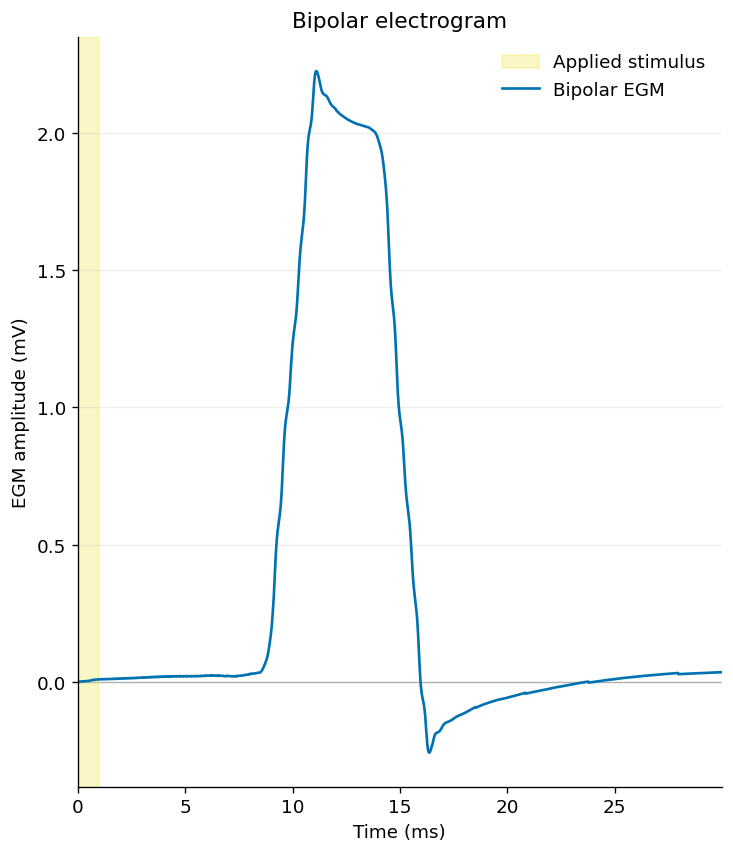

In [35]:
sample_times = egm_tracker.tracking_times
bipolar_egm = egm_tracker.output

fig, ax = plt.subplots(figsize=(6, 7), layout="constrained")
ax.axhline(0, color="0.7", linewidth=0.8, zorder=0)
ax.axvspan(stimulus_start, stimulus_start + stimulus_duration,
           color="#F0E442", alpha=0.3, label="Applied stimulus")
ax.plot(sample_times, bipolar_egm, color=negative_color, linewidth=1.6, label="Bipolar EGM")
ax.set(title="Bipolar electrogram", xlabel="Time (ms)", ylabel="EGM amplitude (mV)",
       xlim=(sample_times[0], sample_times[-1]))
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="best", frameon=False)
plt.show()


## Scope and useful checks

This example contains one isotropic tissue domain and two prescribed-potential contact patches. It does not explicitly represent blood, a surrounding torso or bath, fiber anisotropy, or electrode-interface impedance. Treat it as a demonstration of the workflow rather than a calibrated clinical recording model.

Before comparing variants, check electrode membership and active-node ordering, solver residuals, and the wave's location. Reversing the weights should reverse the EGM, and multiplying them by a constant should scale it by that constant. For resolution studies, refine `dr` and the simulation time step `dt` while preserving physical geometry and contact size; the present patch-count normalization also changes with resolution and must be accounted for when comparing amplitudes.

For multiple leads, compute one weight vector per electrode configuration and stack them with shape `(n_leads, n_tissue_nodes)`. Fixed geometry allows these weights to be reused over time. The computational benefit of precomputed leads is discussed by [Potse (2018)](https://doi.org/10.3389/fphys.2018.00370).

## References

1. Malmivuo, J., and Plonsey, R. (1995). *Bioelectromagnetism: Principles and Applications of Bioelectric and Biomagnetic Fields*. Oxford University Press. [Chapter 11, especially Section 11.6: lead fields and reciprocity](https://bem.fi/book/11/11.htm). Background on scalar reciprocal potentials, vector lead fields, and unit-current normalization.
2. Potse, M. (2018). *Scalable and Accurate ECG Simulation for Reaction-Diffusion Models of the Human Heart*. Frontiers in Physiology, **9**, 370. [doi:10.3389/fphys.2018.00370](https://doi.org/10.3389/fphys.2018.00370). Application of lead-field methods to efficient cardiac signal computation; the present simplified boundary conditions are not a reproduction of its full model.
3. Luo, C. H., and Rudy, Y. (1991). *A model of the ventricular cardiac action potential. Depolarization, repolarization, and their interaction*. Circulation Research, **68**(6), 1501–1526. [doi:10.1161/01.RES.68.6.1501](https://doi.org/10.1161/01.RES.68.6.1501). Source of the cellular model used by `fw.LuoRudy91()`.